## kk1 - Bank churn dataset

## 1. Inledning — kontext

Datasetet innehåller information om bankkunder. Varje rad representerar en kund och innehåller bland annat information om kreditvärdighet, kön, ålder,land samt om kunden valt att lämna banken. syftet med analysen är att försöka se vad det är som gör att kunden lämnar banken.

Jag är dessvärre lite osäker vart jag hämtade datasetet, då det gjordes för länge sedan. jag har försökt leta och hittat liknande men inte den som matchar.

## 2. Inläsning och mekanisk inspektion

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Bank_Churn.csv")

df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
print("Info")
df.info()

print("Statistik")
df.describe()

Info
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB
Statistik


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 3. Datatvätt

Här kontrollerar vi om datasetet saknar värden, dubletter eller felaktiga datatyper.

In [46]:
print("Saknade värden per kolumn:", df.isna().sum())
print("Antal dubbletter:", df.duplicated().sum())

Saknade värden per kolumn: CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Antal dubbletter: 0


Datasetet innehåller inga saknade värden, dubletter eller felaktiga datatyper.

## 4. Utforskning genom visualisering

### Visualisering 1
**Fråga:** Hur stor andel av kunderna lämnar banken?

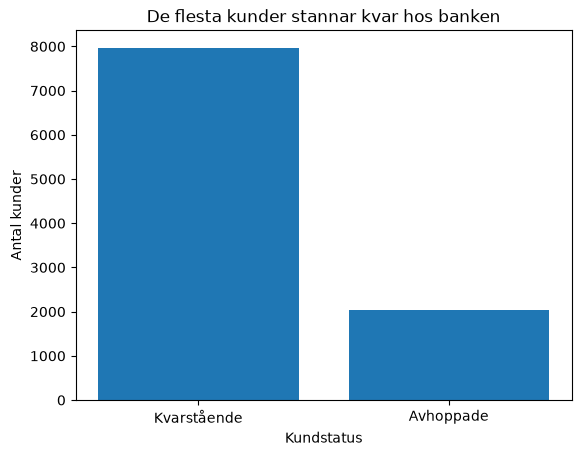

In [47]:

churn_counts = df['Exited'].value_counts()

plt.figure()
plt.bar(['Kvarstående', 'Avhoppade'], churn_counts)
plt.title('De flesta kunder stannar kvar hos banken')
plt.xlabel('Kundstatus')
plt.ylabel('Antal kunder')
plt.show()

Bilden visar att nästan 8000 stannar kvar och 2000 har hoppat av/lämnat banken.